# 04 · ECCO LLC90: actual grid and seam mappings
Use the packaged user-provided LLC90 grid and its 2,312 seamEdges. The tile axis itself adds no adjacency; cross-tile connections use only the supplied pairs. No connections are inferred from tile numbers.
Synthetic two-cell MHW inputs test the actual topology; they do not establish agreement on a real large four-dimensional MHW array.

In [1]:
include(isfile("bootstrap.jl") ? "bootstrap.jl" : "notebooks/bootstrap.jl")
gridfile=joinpath(ROOT,"test","fixtures","llc90_topology.mat")
grid=matread(gridfile)
topology=load_seam_edges(gridfile)
horizontal=CartesianIndices(topology.grid_size)
XC,YC=Float64.(grid["XC"]),Float64.(grid["YC"])
edges=topology.seam_edges
@test size(edges)==(2312,2)
println("Grid: ",topology.grid_size," | seam pairs: ",size(edges,1))

  Activating 

Julia 1

project at `/Volumes/new_drive/lagrangian/julia/notebooks`


.12.3 | MHWTracking 0.1.0
Grid: 

(90, 90, 13) | seam pairs: 2312


## Geographic grid distribution and seam counts between tiles
The left panel subsamples actual XC/YC centers, colored by tile ID, without rearranging tiles into a regular longitude/latitude grid. The right panel displays seam-pair counts symmetrically.

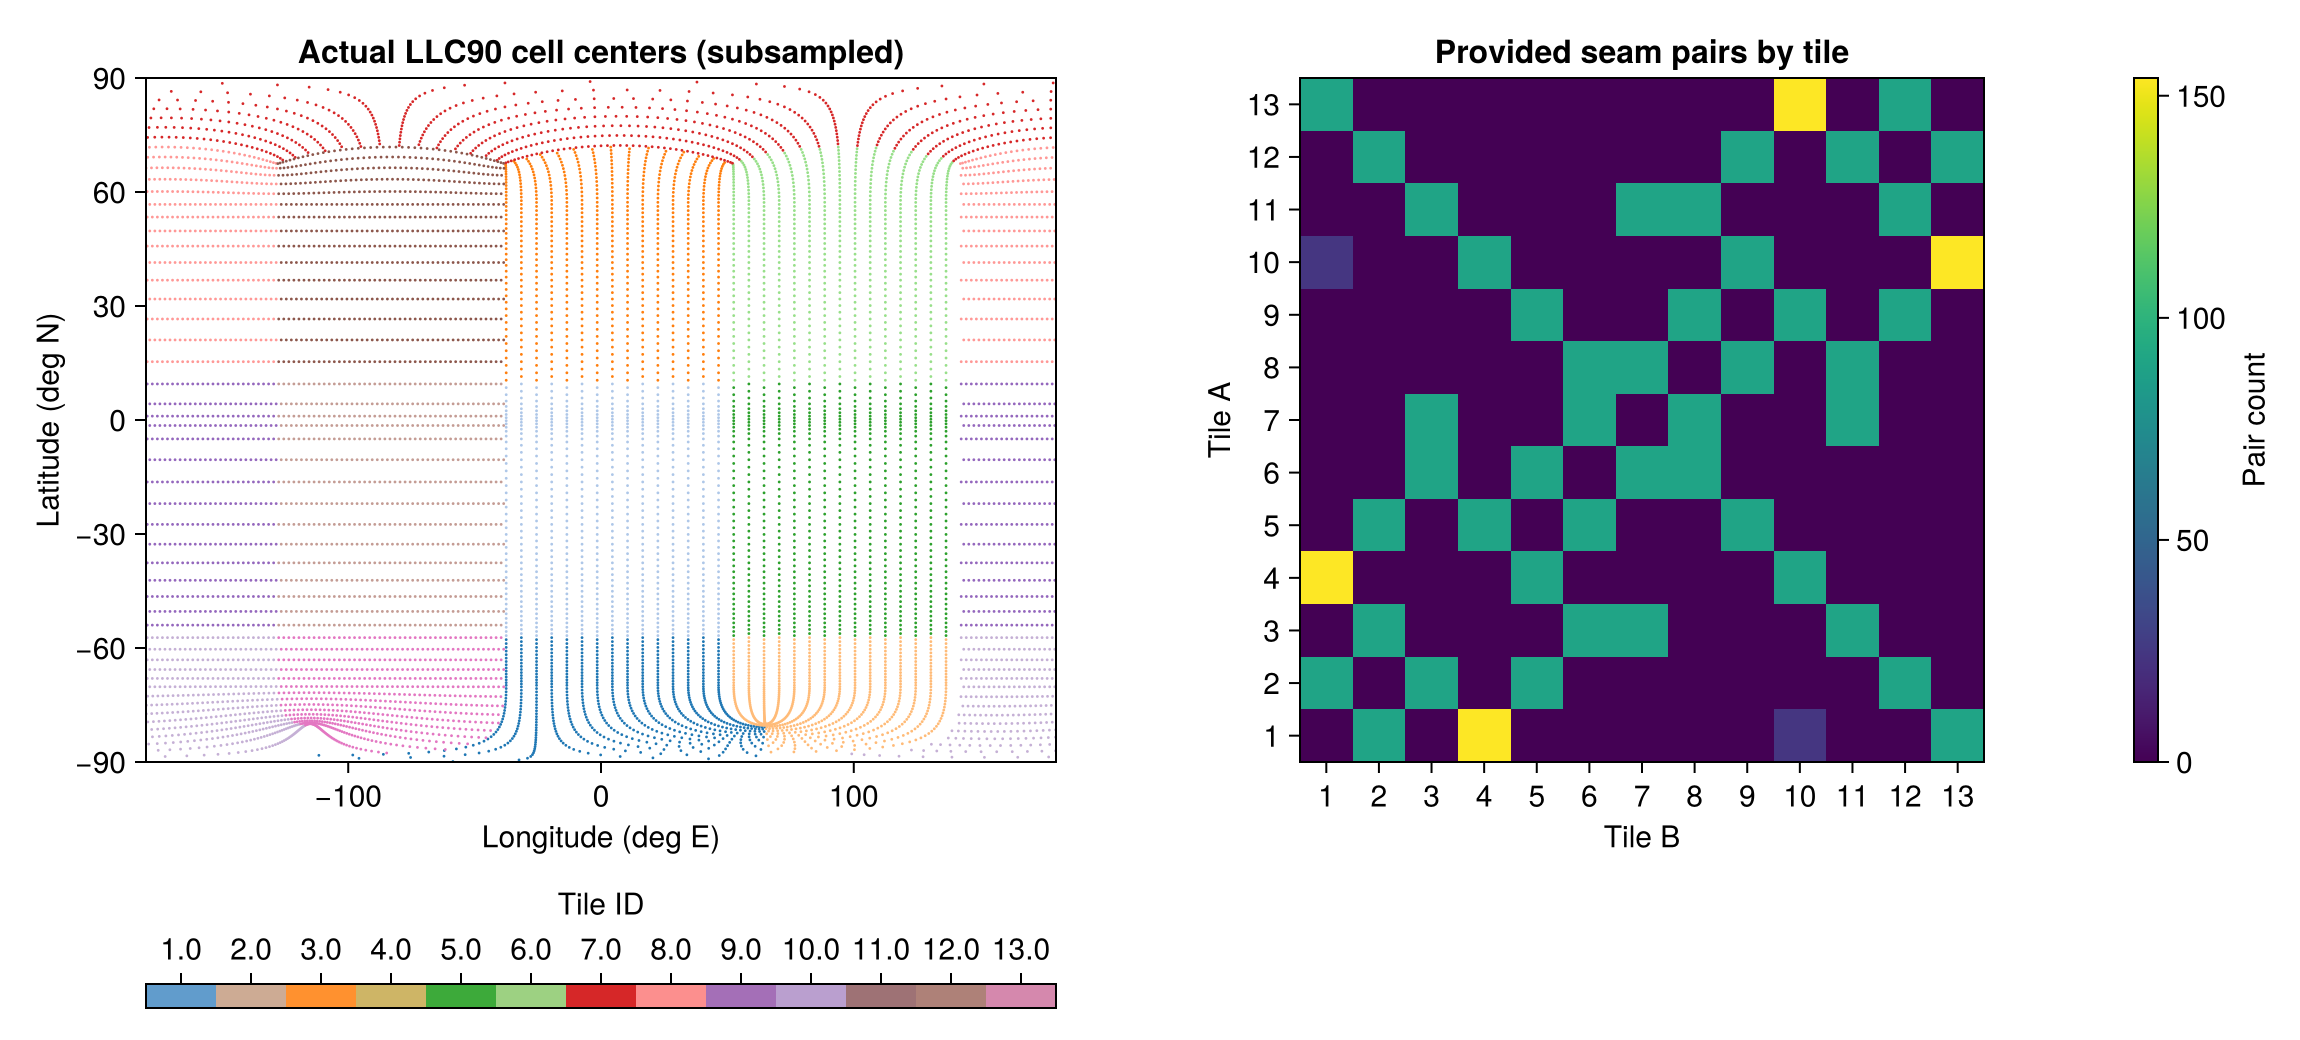

In [2]:
seam_counts=zeros(Int,13,13)
for (a,b) in eachrow(edges)
    ta,tb=horizontal[a][3],horizontal[b][3]
    seam_counts[ta,tb]+=1; seam_counts[tb,ta]+=1
end
fig=Figure(size=(1150,520))
ax=Axis(fig[1,1],title="Actual LLC90 cell centers (subsampled)",xlabel="Longitude (deg E)",ylabel="Latitude (deg N)")
ids=collect(1:12:length(XC)); tile=[horizontal[i][3] for i in ids]
sc=scatter!(ax,vec(XC)[ids],vec(YC)[ids];color=tile,
    colormap=Makie.Categorical(Makie.categorical_colors(:tab20,13)),colorrange=(0.5,13.5),markersize=2)
Colorbar(fig[2,1],sc;vertical=false,label="Tile ID",ticks=1:13)
xlims!(ax,-180,180); ylims!(ax,-90,90)
ax2=Axis(fig[1,2],title="Provided seam pairs by tile",xlabel="Tile B",ylabel="Tile A",aspect=DataAspect(),xticks=1:13,yticks=1:13)
hm=heatmap!(ax2,1:13,1:13,seam_counts;colormap=:viridis)
Colorbar(fig[1,3],hm,label="Pair count")
emit_figure(fig,"04_llc_geography_and_topology")

## Inspect the actual orientation of one tile pair
Select the tile pair with the most seams and plot endpoint i/j coordinates in the supplied pair order. Points with matching sequence numbers define the connection; do not flip an edge based on its apparent direction.

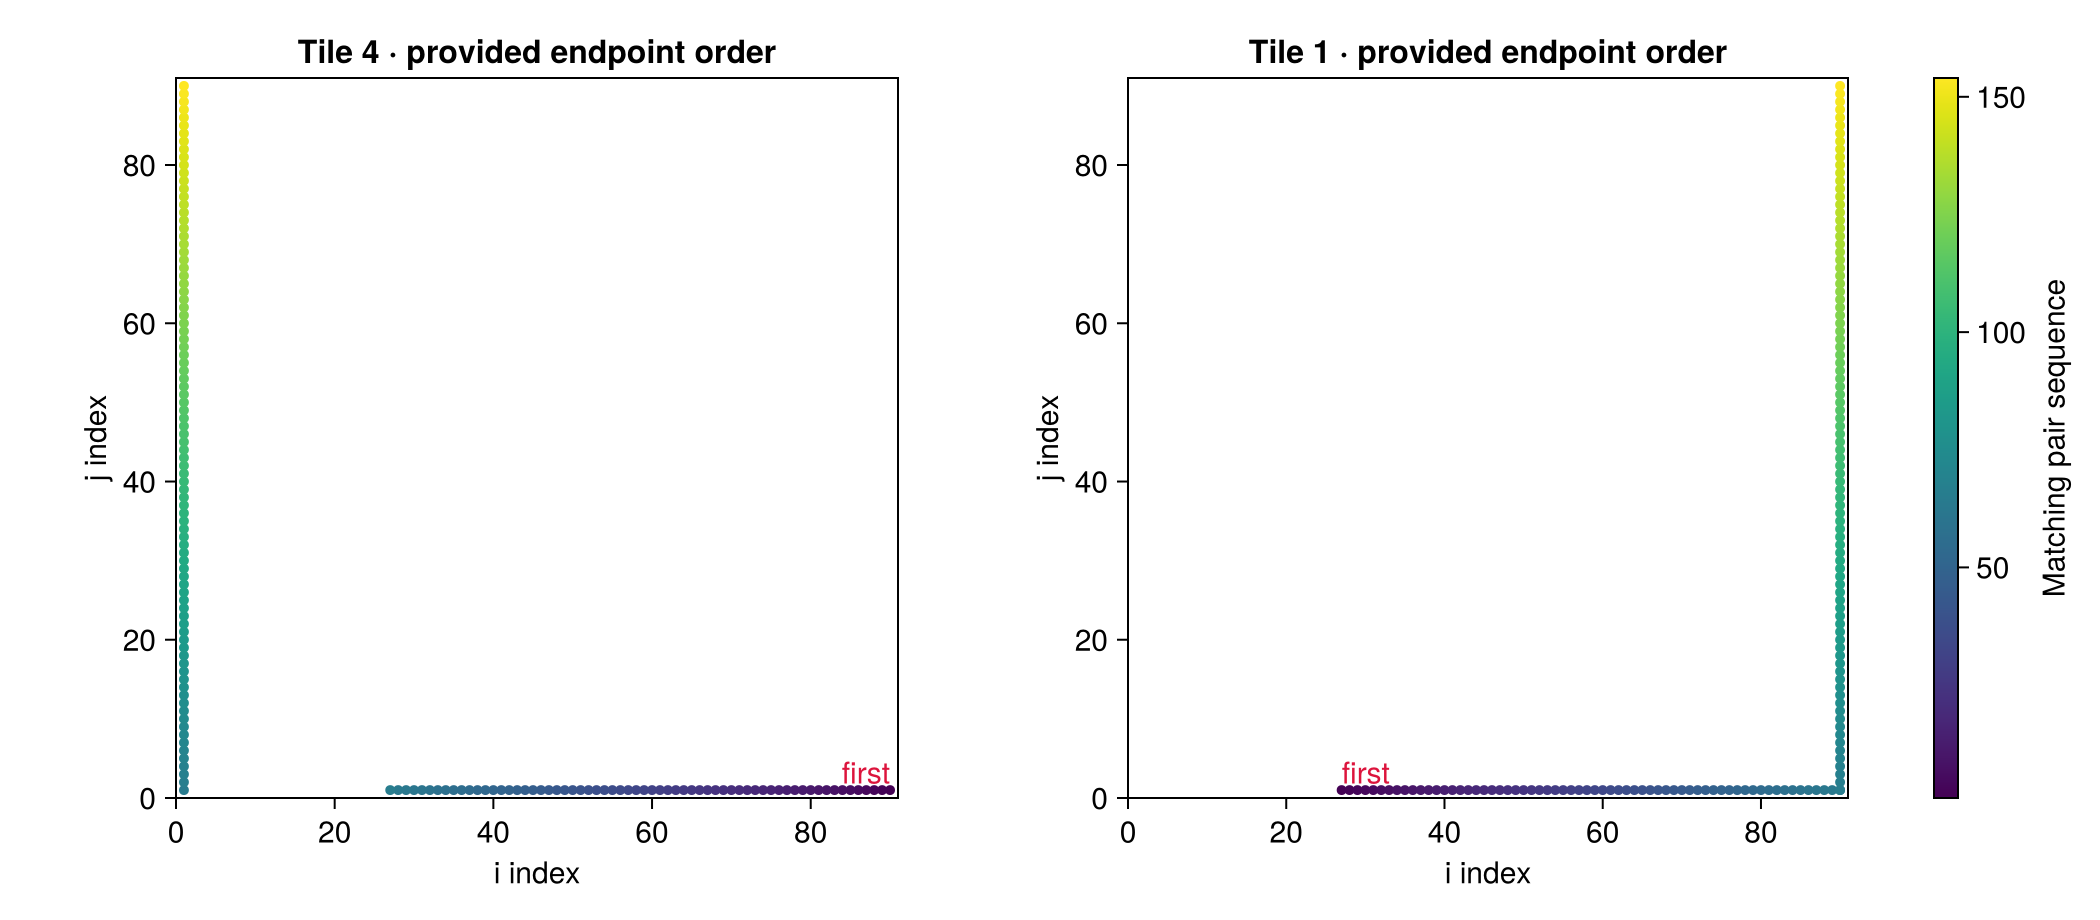

In [3]:
pair_index=argmax(seam_counts)
ta,tb=Tuple(pair_index)
pair_rows=findall(r->Set([horizontal[edges[r,1]][3],horizontal[edges[r,2]][3]])==Set([ta,tb]),axes(edges,1))
side_a=Int[]; side_b=Int[]
for row in pair_rows
    a,b=edges[row,:]
    if horizontal[a][3]==ta
        push!(side_a,a); push!(side_b,b)
    else
        push!(side_a,b); push!(side_b,a)
    end
end
fig=Figure(size=(1050,460))
for (c,(tile,ids)) in enumerate([(ta,side_a),(tb,side_b)])
    ax=Axis(fig[1,c],title="Tile $tile · provided endpoint order",xlabel="i index",ylabel="j index",aspect=DataAspect())
    scatter!(ax,[horizontal[i][1] for i in ids],[horizontal[i][2] for i in ids];
        color=collect(1:length(ids)),colormap=:viridis,colorrange=(1,length(ids)),markersize=7)
    xlims!(ax,0,91); ylims!(ax,0,91)
    p=horizontal[ids[1]]
    text!(ax,p[1],p[2];text="first",align=(p[1]>80 ? :right : :left,:bottom),color=:crimson)
end
Colorbar(fig[1,3];colormap=:viridis,limits=(1,length(side_a)),label="Matching pair sequence")
emit_figure(fig,"04_llc_orientation")

## Cross-seam depth/time diagonals and two-step gaps
Inputs retain all five dimensions `[i,j,tile,depth,time]`. A one-step depth/time diagonal connects; a gap of two in either direction does not. Complete voxel membership is compared.

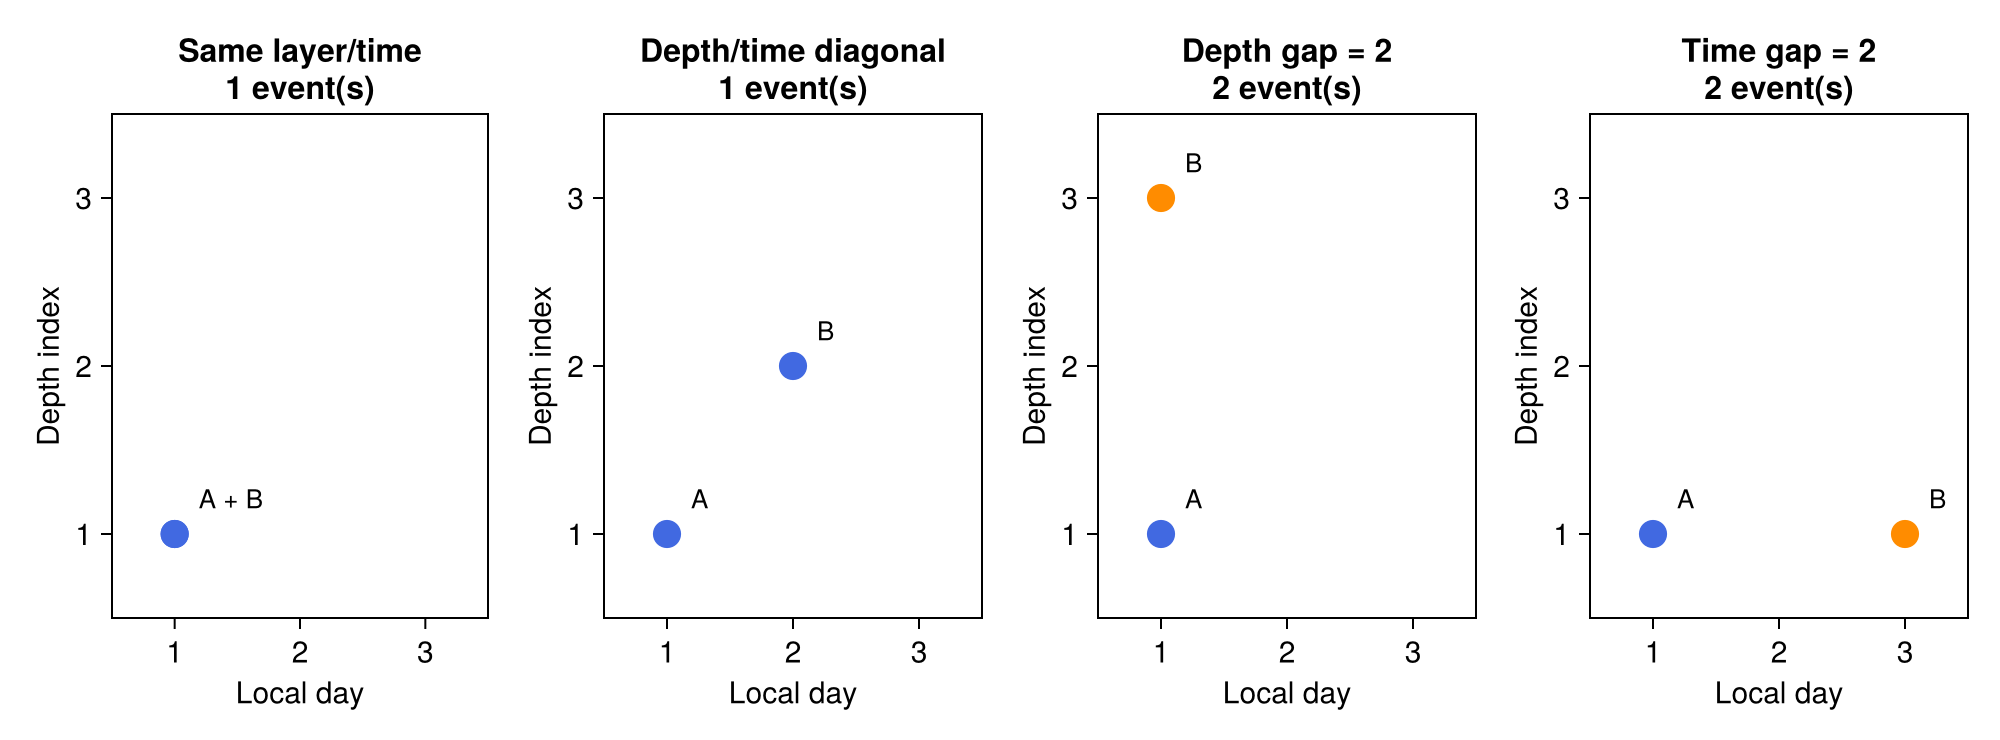

In [4]:
a,b=edges[first(pair_rows),:]; n2=prod(topology.grid_size)
cases=[("Same layer/time",1,1,1,1,1),
       ("Depth/time diagonal",1,2,1,2,1),
       ("Depth gap = 2",1,3,1,1,2),
       ("Time gap = 2",1,1,1,3,2)]
fig=Figure(size=(1000,370))
for (c,(name,za,zb,da,db,expected)) in enumerate(cases)
    dims=(topology.grid_size...,3,3)
    ia=a+(za-1)*n2+(da-1)*n2*3; ib=b+(zb-1)*n2+(db-1)*n2*3
    result,info=track_mhw_4d_llc(SparseMask(dims,[ia,ib]),topology;min_duration=1)
    @test length(result)==expected
    memberships=expected==1 ? [sort(UInt64[ia,ib])] : sort([[UInt64(ia)],[UInt64(ib)]])
    @test event_partition(result)==memberships
    ax=Axis(fig[1,c],title="$name\n$expected event(s)",xlabel="Local day",ylabel="Depth index",xticks=1:3,yticks=1:3)
    scatter!(ax,[da,db],[za,zb];color=expected==1 ? [:royalblue,:royalblue] : [:royalblue,:darkorange],markersize=20)
    if da==db && za==zb
        text!(ax,da,za;text="A + B",offset=(12,10),fontsize=13)
    else
        text!(ax,[da,db],[za,zb];text=["A","B"],offset=(12,10),fontsize=13)
    end
    xlims!(ax,0.5,3.5); ylims!(ax,0.5,3.5)
end
emit_figure(fig,"04_llc_seam_cases")

## Exhaustive seam validation
Reuse the delivered validation script to check all 2,312 seams under five configurations, totaling 11,560 independent pairs.
Four-step local time slots isolate cases. Each batch checks the raw component count and complete event partition, for 1,450 assertions.

In [5]:
include(joinpath(ROOT,"validation","validate_seams.jl"))

same passed for 

2312 edges


forwardDiagonal passed for 2312 edges


reverseDiagonal passed for 2312 edges


depthGapTwo passed for 

2312 edges


timeGapTwo passed for 

2312 edges


Test Summary:                    | Pass  Total  Time
All 2312 actual LLC90 seam edges | 1450   1450  0.5s


## Synthetic four-dimensional MATLAB references
Also compare event/day/idx5/nvoxels with actual outputs from the original MATLAB implementation as a numeric reference for cross-tile connectivity.

In [6]:
f=matread(joinpath(ROOT,"test","fixtures","llc4d.mat"))
small_topology=LLCTopology(f["seamEdges"],(3,2,2))
@testset "LLC MATLAB synthetic fixtures" begin
    for i in eachindex(f["masks"])
        actual,_=track_mhw_4d_llc(f["masks"][i],small_topology;min_duration=1)
        expected=indexed_from_mat(f["tracks"][i],5)
        @test strict_indexed_equal(actual,expected)
        @test partition_equal(actual,expected)
    end
end

Test Summary:                 | Pass  

Total  Time
LLC MATLAB synthetic fixtures |   10     10  0.6s


Test.DefaultTestSet("LLC MATLAB synthetic fixtures", Any[], 10, false, false, true, 1.791466752722076e9, 1.791466753296105e9, false, "In[6]", Random.Xoshiro(0x75f2caec901e6786, 0x957538b6799573fb, 0xcf9095851251a4cb, 0x3dca8a35b33c7ad0, 0xf4af28213f1e571e))